In [59]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
all_tornados = pd.read_csv('data\\1950-2021_actual_tornadoes.csv')

In [6]:
all_tornados

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
0,192,1950,10,1,1950-10-01,21:00:00,3,OK,40,23,...,15.80,10,1,1,1,25,0,0,0,0
1,193,1950,10,9,1950-10-09,02:15:00,3,NC,37,9,...,2.00,880,1,1,1,47,0,0,0,0
2,195,1950,11,20,1950-11-20,02:20:00,3,KY,21,1,...,0.10,10,1,1,1,177,0,0,0,0
3,196,1950,11,20,1950-11-20,04:00:00,3,KY,21,2,...,0.10,10,1,1,1,209,0,0,0,0
4,197,1950,11,20,1950-11-20,07:30:00,3,MS,28,14,...,2.00,37,1,1,1,101,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,620523,2021,9,8,2021-09-08,15:32:00,3,PA,42,0,...,0.73,30,1,1,1,109,0,0,0,0
67554,620524,2021,9,8,2021-09-08,15:35:00,3,PA,42,0,...,1.45,30,1,1,1,109,0,0,0,0
67555,620525,2021,9,8,2021-09-08,19:08:00,3,FL,12,0,...,1.45,50,1,1,1,129,0,0,0,0
67556,620526,2021,9,9,2021-09-09,02:10:00,3,CT,9,0,...,0.75,75,1,1,1,13,0,0,0,0


In [ ]:
sel_states = ['IL', 'IN', 'WI', 'MI', 'MO','IO', 'MN']
Midwest_Tornadoes = all_tornados[all_tornados['st'].isin(sel_states)]
Midwest_Tornadoes.set_index(pd.to_datetime(Midwest_Tornadoes['date']), inplace = True)
Midwest_tor_count = Midwest_Tornadoes.resample('MS').size()


In [55]:
EPNA_data = pd.read_csv('data\\EPNA_1951_2025')
EPNA_data.rename(columns = {'Date': 'date'}, inplace = True)
EPNA_data['date'] = pd.to_datetime(EPNA_data['date'])
EPNA_data.set_index('date', inplace = True)

Mw_Tor_Tele = pd.merge(left = Midwest_tor_count.rename('monthly_count'), right = EPNA_data, on = 'date', how = 'inner')

In [58]:
Mw_Tor_Tele

,monthly_count,ENSO,PDO,NAO,AO
date,,,,,
1951-01-01,0,1.5,-1.19,0.08,-0.085
1951-02-01,0,0.9,-1.52,0.70,-0.400
1951-03-01,1,-0.1,-1.72,-1.02,-1.934
1951-04-01,0,-0.3,-1.35,-0.22,-0.776
1951-05-01,2,-0.7,-1.29,-0.59,-0.863
...,...,...,...,...,...
2021-08-01,45,0.6,-0.95,-0.28,-0.209
2021-09-01,7,0.8,-1.96,-0.21,-0.252
2021-10-01,42,0.7,-3.13,-2.29,-0.146


In [ ]:
# Checking for missing values

Mw_Tor_Tele.isna().sum()

monthly_count    0
ENSO             0
PDO              0
NAO              0
AO               0
dtype: int64

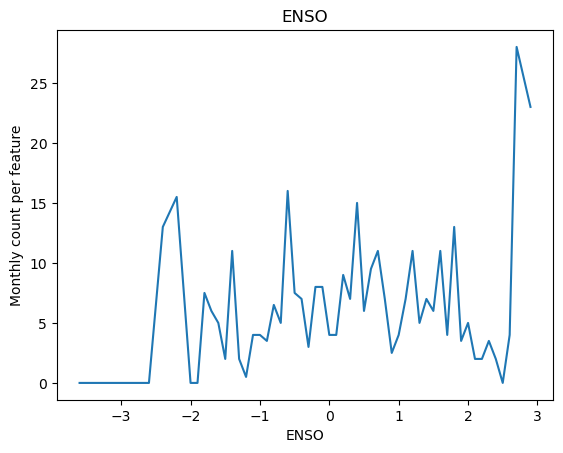

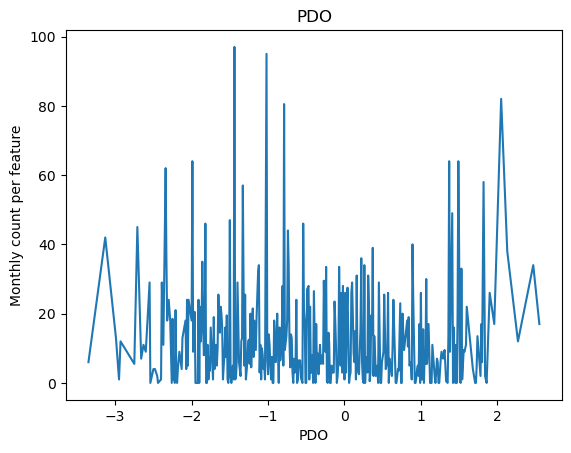

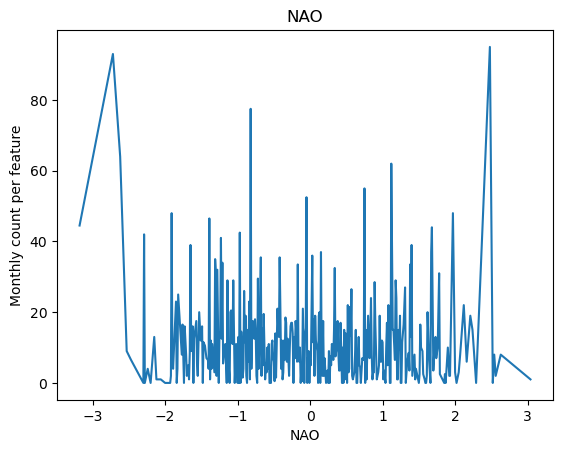

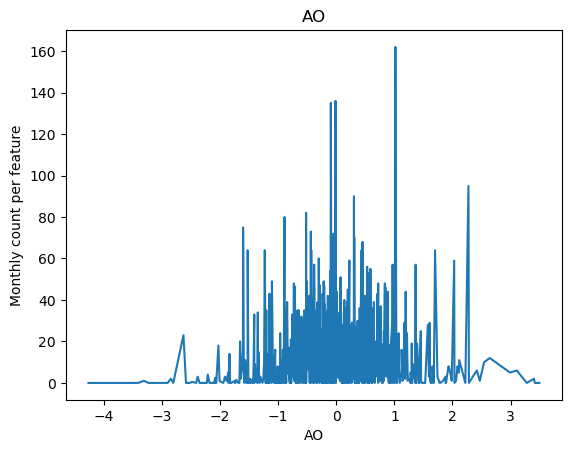

In [60]:
training_features = ['ENSO', 'PDO', 'NAO', 'AO']

for feature in training_features:
    Mw_Tor_Tele.groupby(feature)['monthly_count'].median().plot()
    plt.ylabel('Monthly count per feature')
    plt.title(feature)
    plt.show()

In [ ]:
param_grid = {
 "max_depth": [10, 25, 50, 100],
 "min_samples_leaf": [1,2,3,4,5],
 "n_estimators": [25, 50, 100, 200, 400]}